In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

In [4]:
audio_folder = "audio"
audio_files = os.listdir(audio_folder)
audio_files

['audio_01.wav',
 'audio_02.wav',
 'audio_03.wav',
 'audio_04.wav',
 'audio_05.wav',
 'audio_06.wav',
 'audio_07.wav',
 'audio_08.wav',
 'audio_09.wav',
 'audio_10.wav',
 'audio_11.wav',
 'audio_12.wav']

In [5]:
audio_path = "audio/audio_01.wav"
audio, sample_rate = librosa.load(audio_path, sr=None)
print("Sample rate:", sample_rate)
print("Number of samples:", len(audio))
print("Duration:", len(audio) / sample_rate, "seconds")

C:\ProgramData\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


Sample rate: 16000
Number of samples: 96000
Duration: 6.0 seconds


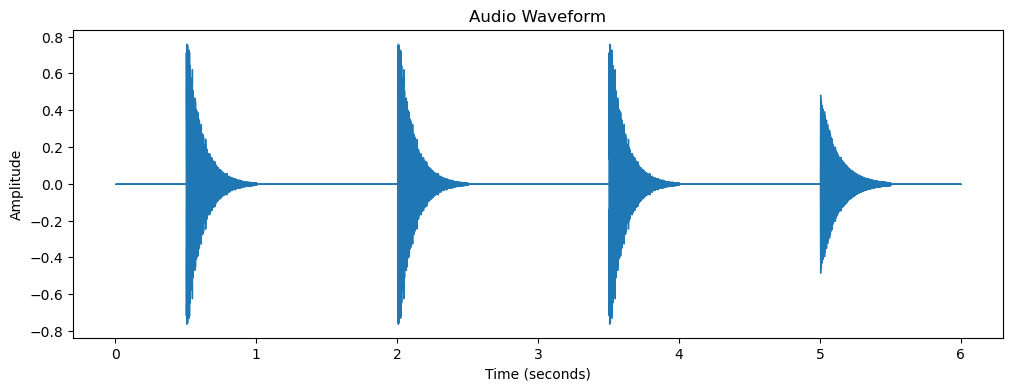

In [6]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio, sr=sample_rate)
plt.title("Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

In [7]:
df = pd.read_csv("data/qa_dataset.csv")
df.head()

,audio_file,question,answer,question_type,split
0,audio_01.wav,What sounds are present?,"dog_bark, door",perceptual,train
1,audio_01.wav,How many times does the dog bark?,3,counting,train
2,audio_01.wav,What happens after the dog bark?,dog bark,temporal,train
3,audio_01.wav,What happens before the door?,dog bark,temporal,train
4,audio_01.wav,Can the exact reason for these sounds be deter...,"No. The audio indicates which sounds occur, bu...",reasoning,train


In [8]:
print("Total questions:", len(df))
print("\nQuestion types:")
print(df["question_type"].value_counts())
print("\nData split:")
print(df["split"].value_counts())

Total questions: 60

Question types:
question_type
temporal      24
perceptual    12
counting      12
reasoning     12
Name: count, dtype: int64

Data split:
split
train         39
test          11
validation    10
Name: count, dtype: int64


In [9]:
import torch
import torchaudio
from transformers import pipeline

In [10]:
classifier = pipeline(
    "audio-classification",
    model="MIT/ast-finetuned-audioset-10-10-0.4593"
)

C:\Users\LENOVO\AppData\Roaming\Python\Python311\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [12]:
import librosa

audio_path = "audio/audio_01.wav"

audio, sample_rate = librosa.load(
    audio_path,
    sr=16000,
    mono=True
)

print("Audio loaded")
print("Sample rate:", sample_rate)
print("Duration:", len(audio) / sample_rate, "seconds")

Audio loaded
Sample rate: 16000
Duration: 6.0 seconds


In [13]:
results = classifier({
    "array": audio,
    "sampling_rate": sample_rate
})

results[:10]

[{'score': 0.29251423478126526, 'label': 'Drum'},
 {'score': 0.17218583822250366, 'label': 'Music'},
 {'score': 0.08498972654342651, 'label': 'Percussion'},
 {'score': 0.06998754292726517, 'label': 'Sound effect'},
 {'score': 0.06496720016002655, 'label': 'Snare drum'}]

In [14]:
for result in results[:10]:
    print(
        result["label"],
        "->",
        round(result["score"], 3)
    )

Drum -> 0.293
Music -> 0.172
Percussion -> 0.085
Sound effect -> 0.07
Snare drum -> 0.065


In [15]:
audio_context = []

for result in results[:5]:
    label = result["label"]
    score = result["score"]

    audio_context.append({
        "sound": label,
        "confidence": round(score, 3)
    })

audio_context

[{'sound': 'Drum', 'confidence': 0.293},
 {'sound': 'Music', 'confidence': 0.172},
 {'sound': 'Percussion', 'confidence': 0.085},
 {'sound': 'Sound effect', 'confidence': 0.07},
 {'sound': 'Snare drum', 'confidence': 0.065}]

In [16]:
def answer_question(question, context):

    question = question.lower()

    if "what sound" in question or "what sounds" in question:

        sounds = [item["sound"] for item in context]

        return "The detected sounds are: " + ", ".join(sounds)

    return "I cannot answer this question yet."

In [17]:
question = "What sounds are present?"

answer = answer_question(question, audio_context)

print("Question:", question)
print("Answer:", answer)

Question: What sounds are present?
Answer: The detected sounds are: Drum, Music, Percussion, Sound effect, Snare drum


In [25]:
print(type(audio_context))
print(audio_context)

<class 'list'>
[{'sound': 'Drum', 'confidence': 0.293}, {'sound': 'Music', 'confidence': 0.172}, {'sound': 'Percussion', 'confidence': 0.085}, {'sound': 'Sound effect', 'confidence': 0.07}, {'sound': 'Snare drum', 'confidence': 0.065}]


In [36]:
def answer_question(question, audio_context):
    question_lower = question.lower()

    sounds = [item["sound"] for item in audio_context]

    # 1. Perceptual question
    if "what sounds" in question_lower or "what sound" in question_lower:
        return "The detected sounds are: " + ", ".join(sounds)

    # 2. Counting question
    elif "how many" in question_lower or "how many times" in question_lower:
        counts = {}

        for sound in sounds:
            counts[sound] = counts.get(sound, 0) + 1

        return "Sound event counts: " + ", ".join(
            f"{sound}: {count}" for sound, count in counts.items()
        )

    # 3. Temporal question
    elif "after the first sound" in question_lower:
        if len(sounds) > 1:
            return f"After the first sound ({sounds[0]}), the next detected sound is {sounds[1]}."
        else:
            return "There is no second detected sound."

    elif "before the last sound" in question_lower:
        if len(sounds) > 1:
            return f"Before the last sound ({sounds[-1]}), the previous detected sound is {sounds[-2]}."
        else:
            return "There is no previous detected sound."

    # 4. Causal / reasoning question
    elif "why" in question_lower:
        return (
            "The exact reason cannot be determined from the audio alone. "
            "The audio can indicate what sounds are present, "
            "but it does not necessarily reveal their exact cause."
        )

    else:
        return "I cannot answer this question yet."
    

In [37]:
question = "How many times does a sound event occur?"

answer = answer_question(question, audio_context)

print("Question:", question)
print("Answer:", answer)

Question: How many times does a sound event occur?
Answer: Sound event counts: Drum: 1, Music: 1, Percussion: 1, Sound effect: 1, Snare drum: 1


In [38]:
question = "What happens after the first sound?"

answer = answer_question(question, audio_context)

print("Question:", question)
print("Answer:", answer)

Question: What happens after the first sound?
Answer: After the first sound (Drum), the next detected sound is Music.


In [39]:
question = "What happens after the first sound?"

answer = answer_question(question, audio_context)

print("Question:", question)
print("Answer:", answer)

Question: What happens after the first sound?
Answer: After the first sound (Drum), the next detected sound is Music.


In [40]:
question = "Why does this sound occur?"

answer = answer_question(question, audio_context)

print("Question:", question)
print("Answer:", answer)

Question: Why does this sound occur?
Answer: The exact reason cannot be determined from the audio alone. The audio can indicate what sounds are present, but it does not necessarily reveal their exact cause.


In [41]:
import pandas as pd

df = pd.read_csv("data/qa_dataset.csv")

print("Total questions:", len(df))
print("\nQuestion types:")
print(df["question_type"].value_counts())

print("\nData split:")
print(df["split"].value_counts())

Total questions: 60

Question types:
question_type
temporal      24
perceptual    12
counting      12
reasoning     12
Name: count, dtype: int64

Data split:
split
train         39
test          11
validation    10
Name: count, dtype: int64


In [42]:
# Check the test-set questions

test_df = df[df["split"] == "test"]

print("Test questions:", len(test_df))
print("\nTest questions by type:")
print(test_df["question_type"].value_counts())

Test questions: 11

Test questions by type:
question_type
temporal      4
counting      3
perceptual    2
reasoning     2
Name: count, dtype: int64
